# Table of Contents

1. Introduction
2. Import Libraries
3. Load and Understand the Dataset
4. Data Cleaning
5. Categorical Encoding
6. Feature Scaling
7. Outlier Detection and Removal
8. Key Insights
9. Final Conclusion

## Introduction

Data cleaning and preprocessing are important steps in preparing raw data for machine learning. Raw datasets may contain missing values, categorical features, inconsistent data types, and outliers that can affect the quality of machine learning models.

In this task, the Titanic dataset was used to understand and apply the basic data preprocessing techniques required before building a machine learning model. The process includes exploring the dataset, handling missing values, converting categorical features into numerical form, standardizing numerical features, and detecting and removing outliers.

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load and Understand Dataset

In [2]:
df=pd.read_csv('/content/Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [6]:
df.shape

(891, 10)

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [9]:
print(df.dtypes)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
dtype: object


In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare'],
      dtype='object')

#Data Cleaning

In [11]:
missing_values = df.isnull().sum()

In [12]:
# Display columns with missing values
missing_values = missing_values[missing_values > 0]
print(missing_values)

Age    177
dtype: int64


In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

PassengerId     0.00000
Survived        0.00000
Pclass          0.00000
Name            0.00000
Sex             0.00000
Age            19.86532
SibSp           0.00000
Parch           0.00000
Ticket          0.00000
Fare            0.00000
dtype: float64


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print('Numerical:',list(numerical_columns))

categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print('Categorical:',list(categorical_columns))

Numerical: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Name', 'Sex', 'Ticket']


In [16]:
# Find the median age

age_median = df['Age'].median()

print("Median Age:", age_median)

Median Age: 28.0


In [17]:
# Fill missing Age values with the median

df['Age'] = df['Age'].fillna(age_median)

print("Missing Age values after cleaning:", df['Age'].isnull().sum())

Missing Age values after cleaning: 0


In [18]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [19]:
df.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708


### Data Cleaning Insights

- The dataset was checked for missing values, data types, and duplicate records.
- The `Age` column contained 177 missing values.
- Missing `Age` values were handled using median imputation.
- The `Name` and `Ticket` columns were identified as text-based features, while `PassengerId` was an identifier.
- `PassengerId`, `Name`, and `Ticket` were removed from the preprocessing dataset.
- After cleaning, the dataset contained no missing values.
- The cleaned dataset was then prepared for categorical encoding, feature scaling, and outlier treatment.

#Categorical Encoding

In [20]:
# Check unique values of important categorical columns

print("Sex:", df['Sex'].unique())
print("Pclass:", df['Pclass'].unique())

Sex: ['male' 'female']
Pclass: [3 1 2]


In [21]:
df = pd.get_dummies( df, columns=['Sex', 'Pclass'], drop_first=True)
print("Categorical encoding completed")

Categorical encoding completed


In [22]:
# Check columns after encoding

print(df.columns.tolist())

['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Sex_male', 'Pclass_2', 'Pclass_3']


In [23]:
# Check data types

df.dtypes

,0
PassengerId,int64
Survived,int64
Name,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Sex_male,bool
Pclass_2,bool


In [24]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])


In [25]:
# Convert boolean features to integers

df['Sex_male'] = df['Sex_male'].astype(int)
df['Pclass_2'] = df['Pclass_2'].astype(int)
df['Pclass_3'] = df['Pclass_3'].astype(int)

In [26]:
df.dtypes

,0
Survived,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,int64
Pclass_2,int64
Pclass_3,int64


### Insight – Categorical Encoding

The categorical features `Sex` and `Pclass` were converted into numerical form using one-hot encoding with `drop_first=True`. This transformation makes the categorical information suitable for machine learning algorithms while avoiding unnecessary duplicate information. The encoded features are represented as `Sex_male`, `Pclass_2`, and `Pclass_3`.

#Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

# Numerical features selected for scaling
scaling_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization
df[scaling_features] = scaler.fit_transform(df[scaling_features])

print("Feature scaling completed!")
print("Dataset shape:", df.shape)

Feature scaling completed!
Dataset shape: (891, 8)


In [28]:
df[scaling_features].head()

,Age,SibSp,Parch,Fare
0,-0.565736,0.432793,-0.473674,-0.502445
1,0.663861,0.432793,-0.473674,0.786845
2,-0.258337,-0.474545,-0.473674,-0.488854
3,0.433312,0.432793,-0.473674,0.420730
4,0.433312,-0.474545,-0.473674,-0.486337


In [29]:
df[scaling_features].describe()

,Age,SibSp,Parch,Fare
count,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.272780e-16,4.386066e-17,5.382900e-17,3.987333e-18
std,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.224156e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01
25%,-5.657365e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01
50%,-1.046374e-01,-4.745452e-01,-4.736736e-01,-3.573909e-01
75%,4.333115e-01,4.327934e-01,-4.736736e-01,-2.424635e-02
max,3.891554e+00,6.784163e+00,6.974147e+00,9.667167e+00


In [30]:
# Detect and remove outliers using IQR

numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']

df_clean = df.copy()

for column in numerical_features:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("Original dataset shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original dataset shape: (891, 8)
After outlier removal: (561, 8)


### Insight – Feature Scaling

Standardization was applied to the numerical features `Age`, `SibSp`, `Parch`, and `Fare` using `StandardScaler`. The features were transformed to a common scale with a mean close to 0 and a standard deviation close to 1. This helps prevent features with larger numerical ranges from dominating machine learning models.

#Outlier Detection & Removal

In [31]:
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']

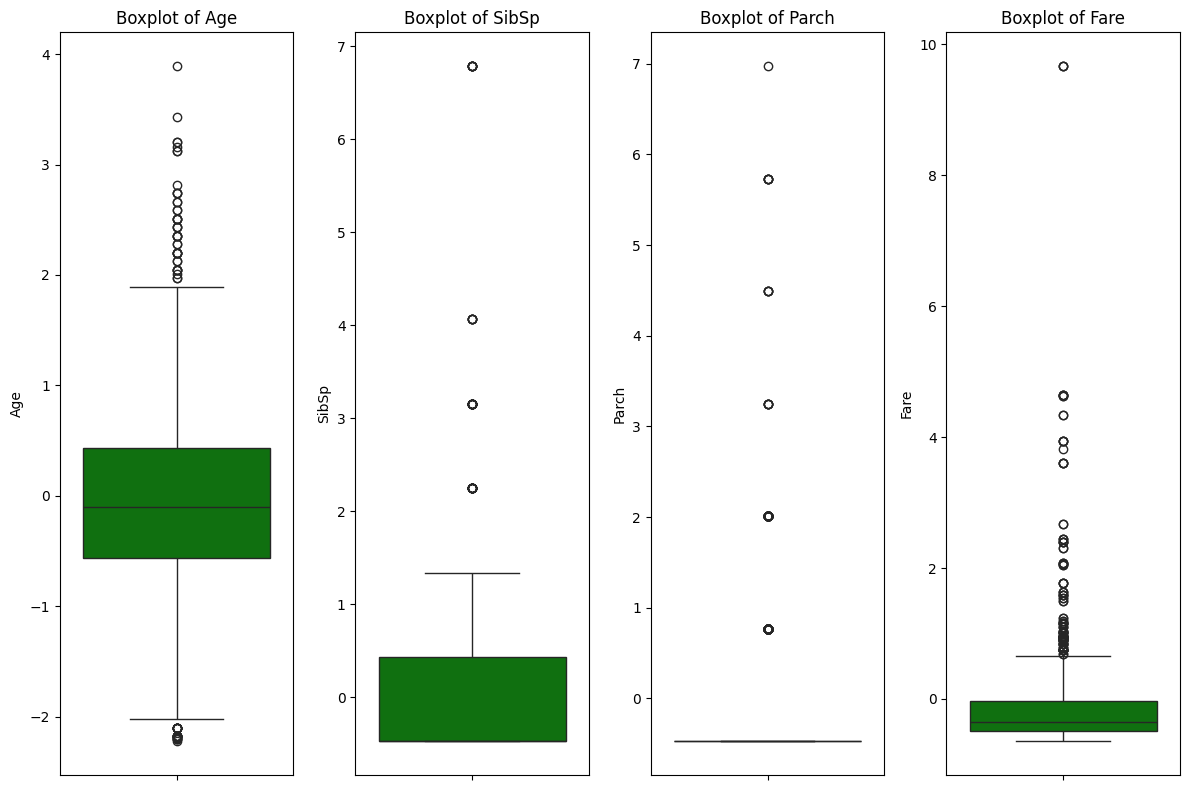

In [32]:
# Visualize outliers using boxplots

plt.figure(figsize=(12, 8))

for i, column in enumerate(numerical_features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[column],color='green')
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

In [43]:
# Check remaining outliers

for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} remaining outliers")

Age: 0 remaining outliers
SibSp: 0 remaining outliers
Parch: 0 remaining outliers
Fare: 0 remaining outliers


In [39]:
# Remove outliers using IQR method

df_clean = df.copy()

for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("Original dataset shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original dataset shape: (891, 8)
After outlier removal: (577, 8)


In [35]:
for column in numerical_features:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} remaining outliers")

Age: 52 remaining outliers
SibSp: 96 remaining outliers
Parch: 0 remaining outliers
Fare: 90 remaining outliers


In [41]:
# Check the final cleaned dataset

print("Final dataset shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing values:")
print(df_clean.isnull().sum())

Final dataset shape: (577, 8)

Columns:
['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Pclass_2', 'Pclass_3']

Missing values:
Survived    0
Age         0
SibSp       0
Parch       0
Fare        0
Sex_male    0
Pclass_2    0
Pclass_3    0
dtype: int64


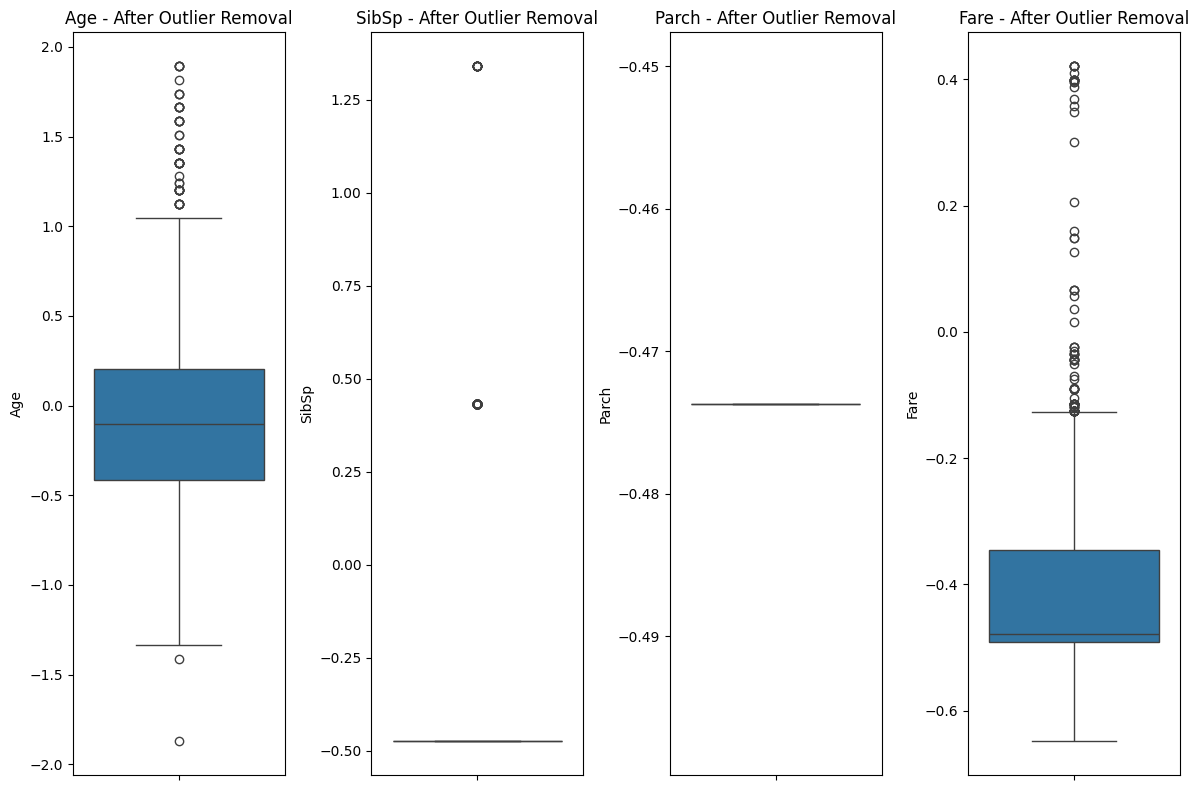

In [37]:
# Boxplots after outlier removal

plt.figure(figsize=(12, 8))

for i, column in enumerate(numerical_features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df_clean[column])
    plt.title(f'{column} - After Outlier Removal')

plt.tight_layout()
plt.show()

In [38]:
print("Final cleaned dataset shape:", df_clean.shape)
df_clean.head()

Final cleaned dataset shape: (561, 8)


,Survived,Age,SibSp,Parch,Fare,Sex_male,Pclass_2,Pclass_3
0,0,-0.565736,0.432793,-0.473674,-0.502445,1,0,1
2,1,-0.258337,-0.474545,-0.473674,-0.488854,0,0,1
3,1,0.433312,0.432793,-0.473674,0.420730,0,0,0
4,0,0.433312,-0.474545,-0.473674,-0.486337,1,0,1
5,0,-0.104637,-0.474545,-0.473674,-0.478116,1,0,1


### Insight – Outlier Detection and Removal

Outliers were identified using boxplots and the Interquartile Range (IQR) method. The IQR method uses the first quartile (Q1), third quartile (Q3), and the limits Q1 − 1.5 × IQR and Q3 + 1.5 × IQR to identify extreme observations.

After removing the detected outliers from the numerical features, the dataset was reduced from 891 records to 561 records while retaining 8 processed columns. This produced a cleaner dataset for further machine learning analysis.

## Key Insights

- The original Titanic dataset contained **891 records and 10 columns**.
- Missing values in the `Age` column were handled using **median imputation**.
- Unnecessary columns such as `PassengerId`, `Name`, and `Ticket` were removed during data cleaning.
- The categorical features `Sex` and `Pclass` were converted into numerical features using **one-hot encoding**.
- The numerical features `Age`, `SibSp`, `Parch`, and `Fare` were standardized using **StandardScaler**.
- Outliers were identified using **boxplots and the IQR method**.
- After outlier removal, the dataset was reduced from **891 records to 561 records**.
- The final processed dataset contains **561 records and 8 columns**, making it suitable for further machine learning analysis.

## Final Conclusion

The Titanic dataset was successfully cleaned and preprocessed by handling missing values, removing unnecessary columns, encoding categorical features, standardizing numerical features, and detecting and removing outliers using the IQR method.

The dataset was transformed from **891 records and 10 original columns** into a processed dataset containing **561 records and 8 columns**. The resulting dataset is structured and prepared for further machine learning analysis and model development.